In [ ]:
# Task 1 - business understanding and data loading

#import the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

#1.1 data loading
df = pd.read_csv ('data/superstore_cleaned.csv',encoding='latin1')

# clean the column names (removes the spaces)
df.columns = df.columns.str.strip()
print("Dataset sucessfully loaded\n")

#display first 10 rows
print("\n---First ten rows---")
display(df.head(10))

#display the last five rows
print("\n---last five rows---")
display(df.tail(5))

#print the shape
print("\n---dataset shape---")
print(f"rows: {df.shape[0]}, columns: {df.shape[1]}")

#1.2 data exploration

#dataset information
print("\n---dataset info---")
df.info()

#summary statistics (all columns)
print("\n ---summary stats---")
display(df.describe(include='all'))

#unique values for key columns
print("\n---unique values---")

if 'Ship Mode' in df.columns :
    print("Ship Mode:", df['Ship Mode'].unique())

if 'Segment' in df.columns :
    print("Segment:", df['Segment'].unique())

if 'Region' in df.columns :
    print("Region:", df['Region'].unique())

if 'Category' in df.columns :
    print("Category:",df['Category'].unique())

In [ ]:
# TASK 2: DATA PREPARATION and CLEANING

# CLEAN COLUMN NAMES
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w]", "", regex=True)
)

print("Cleaned Columns:")
print(df.columns.tolist())

# AUTO-DETECT IMPORTANT COLUMNS
def find_col(possible_names):
    for name in possible_names:
        for COL in df.columns:
            if COL == name:
                return COL
    for name in possible_names:
        for COL in df.columns:
            if name in COL:
                return COL
    return None

order_date_col = find_col(["order_date"])
ship_date_col = find_col(["ship_date"])
sales_col = find_col(["sales"])
profit_col = find_col(["profit"])
discount_col = find_col(["discount"])
order_id_col = find_col(["order_id", "orderid"])

print("\nDetected Columns:")
print("order_date_col:", order_date_col)
print("ship_date_col:", ship_date_col)
print("sales_col:", sales_col)
print("profit_col:", profit_col)
print("discount_col:", discount_col)
print("order_id_col:", order_id_col)

# 2.1 MISSING VALUES
print("\n=== Missing Values ===")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})
display(missing_table)

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()

# 2.2 DUPLICATES
print("\n=== Duplicate Analysis ===")
duplicate_rows = df.duplicated().sum()
print("Exact duplicate rows:", duplicate_rows)

df = df.drop_duplicates()
print("Shape after removing exact duplicates:", df.shape)

if order_id_col:
    duplicate_order_ids = df[order_id_col].duplicated().sum()
    print("Duplicate Order IDs (valid multiple items per order):", duplicate_order_ids)

# 2.3 DATA TYPE CONVERSION

print("\n=== Data Type Conversion ===")

# Convert dates
if order_date_col:
    df[order_date_col] = pd.to_datetime(df[order_date_col], errors="coerce")

if ship_date_col:
    df[ship_date_col] = pd.to_datetime(df[ship_date_col], errors="coerce")

# Convert numeric columns safely
for col in [sales_col, profit_col, discount_col]:
    if col:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.replace("%", "", regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Shipping days
if order_date_col and ship_date_col:
    df["shipping_days"] = (df[ship_date_col] - df[order_date_col]).dt.days

# Profit margin
if sales_col and profit_col:
    df["profit_margin"] = np.where(
        df[sales_col] != 0,
        (df[profit_col] / df[sales_col]) * 100,
        np.nan
    )

# Extract year and month
if order_date_col:
    df["order_year"] = df[order_date_col].dt.year
    df["order_month"] = df[order_date_col].dt.month

print("Updated data types:")
print(df.dtypes)

display(df.head())

# 2.4 OUTLIER DETECTION
print("\n=== Outlier Detection ===")

def detect_outliers(column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - (1.5 * iqr)
    upper = q3 + (1.5 * iqr)
    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"\nColumn: {column}")
    print(f"q1 = {q1}")
    print(f"q3 = {q3}")
    print(f"iqr = {iqr}")
    print(f"Lower Bound = {lower}")
    print(f"Upper Bound = {upper}")
    print(f"Number of Outliers = {len(outliers)}")

for col in [sales_col, profit_col, discount_col]:
    if col and pd.api.types.is_numeric_dtype(df[col]):
        detect_outliers(col)

# Boxplots
plt.figure(figsize=(12, 5))

if sales_col and pd.api.types.is_numeric_dtype(df[sales_col]):
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[sales_col])
    plt.title("Sales Distribution")

if profit_col and pd.api.types.is_numeric_dtype(df[profit_col]):
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[profit_col])
    plt.title("Profit Distribution")

plt.tight_layout()
plt.show()

In [ ]:
# TASK 3: EXPLORATORY DATA ANALYSIS

# CLEAN COLUMN NAMES

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w]", "", regex=True)
)

print("Columns:")
print(df.columns.tolist())


# AUTO-DETECT IMPORTANT COLUMNS
def find_col(possible_names):
    for name in possible_names:
        for COL in df.columns:
            if COL == name:
                return COL
    for name in possible_names:
        for COL in df.columns:
            if name in COL:
                return COL
    return None


order_date_col = find_col(["order_date"])
sales_col = find_col(["sales"])
profit_col = find_col(["profit"])
discount_col = find_col(["discount"])
quantity_col = find_col(["quantity"])
category_col = find_col(["category"])
subcat_col = find_col(["sub_category", "subcategory"])
region_col = find_col(["region"])
segment_col = find_col(["segment"])
product_name_col = find_col(["product_name", "productname"])

print("\nDetected Columns:")
print("order_date_col :", order_date_col)
print("sales_col      :", sales_col)
print("profit_col     :", profit_col)
print("discount_col   :", discount_col)
print("quantity_col   :", quantity_col)
print("category_col   :", category_col)
print("subcat_col     :", subcat_col)
print("region_col     :", region_col)
print("segment_col    :", segment_col)
print("product_name   :", product_name_col)

# TYPE FIXES

if order_date_col:
    df[order_date_col] = pd.to_datetime(df[order_date_col], errors="coerce")

for col in [sales_col, profit_col, discount_col, quantity_col]:
    if col:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.replace("%", "", regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Create profit_margin if not already there
if sales_col and profit_col:
    df["profit_margin"] = np.where(
        df[sales_col] != 0,
        (df[profit_col] / df[sales_col]) * 100,
        np.nan
    )

# Create year-month for monthly trend
if order_date_col:
    df["year_month"] = df[order_date_col].dt.to_period("M").astype(str)

# 3.1 DESCRIPTIVE STATISTICS WITH NUMPY

print("\n" + "=" * 60)
print("3.1 DESCRIPTIVE STATISTICS WITH NUMPY")
print("=" * 60)

sales_array = df[sales_col].dropna().to_numpy() if sales_col else np.array([])
profit_array = df[profit_col].dropna().to_numpy() if profit_col else np.array([])


def describe_numpy(arr, name):
    if len(arr) == 0:
        print(f"\n{name}: No data available")
        return

    mean_val = np.mean(arr)
    median_val = np.median(arr)
    std_val = np.std(arr)
    p25, p50, p75 = np.percentile(arr, [25, 50, 75])
    min_val = np.min(arr)
    max_val = np.max(arr)
    range_val = np.ptp(arr)

    if mean_val > median_val:
        skew = "Right-skewed"
    elif mean_val < median_val:
        skew = "Left-skewed"
    else:
        skew = "Symmetric"

    print(f"\n{name} Statistics")
    print("-" * 40)
    print(f"Mean: {mean_val:.2f}")
    print(f"Median: {median_val:.2f}")
    print(f"Standard Deviation: {std_val:.2f}")
    print(f"25th Percentile: {p25:.2f}")
    print(f"50th Percentile: {p50:.2f}")
    print(f"75th Percentile: {p75:.2f}")
    print(f"Minimum: {min_val:.2f}")
    print(f"Maximum: {max_val:.2f}")
    print(f"Range: {range_val:.2f}")
    print(f"Skewness Interpretation: {skew}")


describe_numpy(sales_array, "Sales")
describe_numpy(profit_array, "Profit")

# 3.2 GROUPED ANALYSIS

print("\n" + "=" * 60)
print("3.2 GROUPED ANALYSIS")
print("=" * 60)

# Total Sales, Total Profit, Average Discount by Category
if category_col and sales_col and profit_col and discount_col:
    category_analysis = df.groupby(category_col).agg(
        total_sales=(sales_col, "sum"),
        total_profit=(profit_col, "sum"),
        average_discount=(discount_col, "mean")
    ).sort_values("total_profit")

    print("\nCategory Analysis:")
    display(category_analysis)
else:
    print("\nCategory analysis could not be completed because one or more required columns are missing.")

# Total Sales and Profit by Region and Segment
if region_col and segment_col and sales_col and profit_col:
    region_segment_analysis = df.groupby([region_col, segment_col]).agg(
        total_sales=(sales_col, "sum"),
        total_profit=(profit_col, "sum")
    ).sort_values("total_profit")

    print("\nRegion and Segment Analysis:")
    display(region_segment_analysis)
else:
    print("\nRegion and segment analysis could not be completed because one or more required columns are missing.")

# Average Profit Margin by Sub-Category
if subcat_col and "profit_margin" in df.columns:
    subcategory_margin = df.groupby(subcat_col).agg(
        average_profit_margin=("profit_margin", "mean")
    ).sort_values("average_profit_margin")

    print("\nAverage Profit Margin by Sub-Category:")
    display(subcategory_margin)
else:
    print("\nSub-category profit margin analysis could not be completed.")

# Monthly Sales Trend
if "year_month" in df.columns and sales_col:
    monthly_sales = df.groupby("year_month").agg(
        monthly_sales=(sales_col, "sum")
    ).reset_index()

    print("\nMonthly Sales Trend:")
    display(monthly_sales.head(12))

    plt.figure(figsize=(12, 5))
    plt.plot(monthly_sales["year_month"], monthly_sales["monthly_sales"], marker="o")
    plt.title("Monthly Sales Trend")
    plt.xlabel("Year-Month")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("\nMonthly sales trend could not be created.")

# 3.3 CORRELATION ANALYSIS

print("\n" + "=" * 60)
print("3.3 CORRELATION ANALYSIS")
print("=" * 60)

numeric_cols = [col for col in [sales_col, quantity_col, discount_col, profit_col] if col]
corr_df = df[numeric_cols].copy()

if len(corr_df.columns) >= 2:
    correlation_matrix = corr_df.corr()

    print("\nCorrelation Matrix:")
    display(correlation_matrix)

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix")
    plt.show()

    # Find strongest positive and negative correlations (excluding diagonal)
    corr_pairs = correlation_matrix.unstack().reset_index()
    corr_pairs.columns = ["Variable_1", "Variable_2", "Correlation"]
    corr_pairs = corr_pairs[corr_pairs["Variable_1"] != corr_pairs["Variable_2"]]

    corr_pairs["pair"] = corr_pairs.apply(
        lambda x: tuple(sorted([x["Variable_1"], x["Variable_2"]])), axis=1
    )
    corr_pairs = corr_pairs.drop_duplicates(subset="pair").drop(columns="pair")

    if not corr_pairs.empty:
        strongest_positive = corr_pairs.loc[corr_pairs["Correlation"].idxmax()]
        strongest_negative = corr_pairs.loc[corr_pairs["Correlation"].idxmin()]

        print("\nStrongest Positive Correlation:")
        print(strongest_positive)

        print("\nStrongest Negative Correlation:")
        print(strongest_negative)

    if discount_col and profit_col:
        discount_profit_corr = correlation_matrix.loc[discount_col, profit_col]
        print(f"\nCorrelation between {discount_col} and {profit_col}: {discount_profit_corr:.2f}")
else:
    print("\nNot enough numeric columns were available to compute a correlation matrix.")

# 3.4 PROFITABILITY INVESTIGATION

print("\n" + "=" * 60)
print("3.4 PROFITABILITY INVESTIGATION")
print("=" * 60)

if profit_col and profit_col in df.columns:
    loss_transactions = df[df[profit_col].notna() & (df[profit_col] < 0)]

    print("\nLoss-making Transactions:")
    display(loss_transactions.head(10))

    total_loss_amount = loss_transactions[profit_col].sum()
    loss_transaction_count = loss_transactions.shape[0]

    print(f"Total Loss Amount: {total_loss_amount:.2f}")
    print(f"Number of Loss-making Transactions: {loss_transaction_count}")

    if loss_transaction_count == 0:
        print("\nNo loss-making transactions were found in the dataset.")
    elif subcat_col and subcat_col in df.columns:
        loss_by_subcategory = (
            loss_transactions
            .groupby(subcat_col)
            .agg(total_loss=(profit_col, "sum"))
            .sort_values("total_loss")
        )

        print("\nLoss by Sub-Category:")
        display(loss_by_subcategory)

        if loss_by_subcategory.empty:
            print("\nNo sub-category loss summary could be created.")
        else:
            worst_subcategory = loss_by_subcategory.index[0]
            worst_loss = loss_by_subcategory.iloc[0, 0]

            print(f"\nSub-Category with Highest Total Losses: {worst_subcategory}")
            print(f"Total Loss in this Sub-Category: {worst_loss:.2f}")
    else:
        print("\nSub-category column was not found, so sub-category loss analysis could not be completed.")
else:
    print("\nProfit column was not found, so profitability investigation could not be completed.")

Task 4

pictures of the dashboard

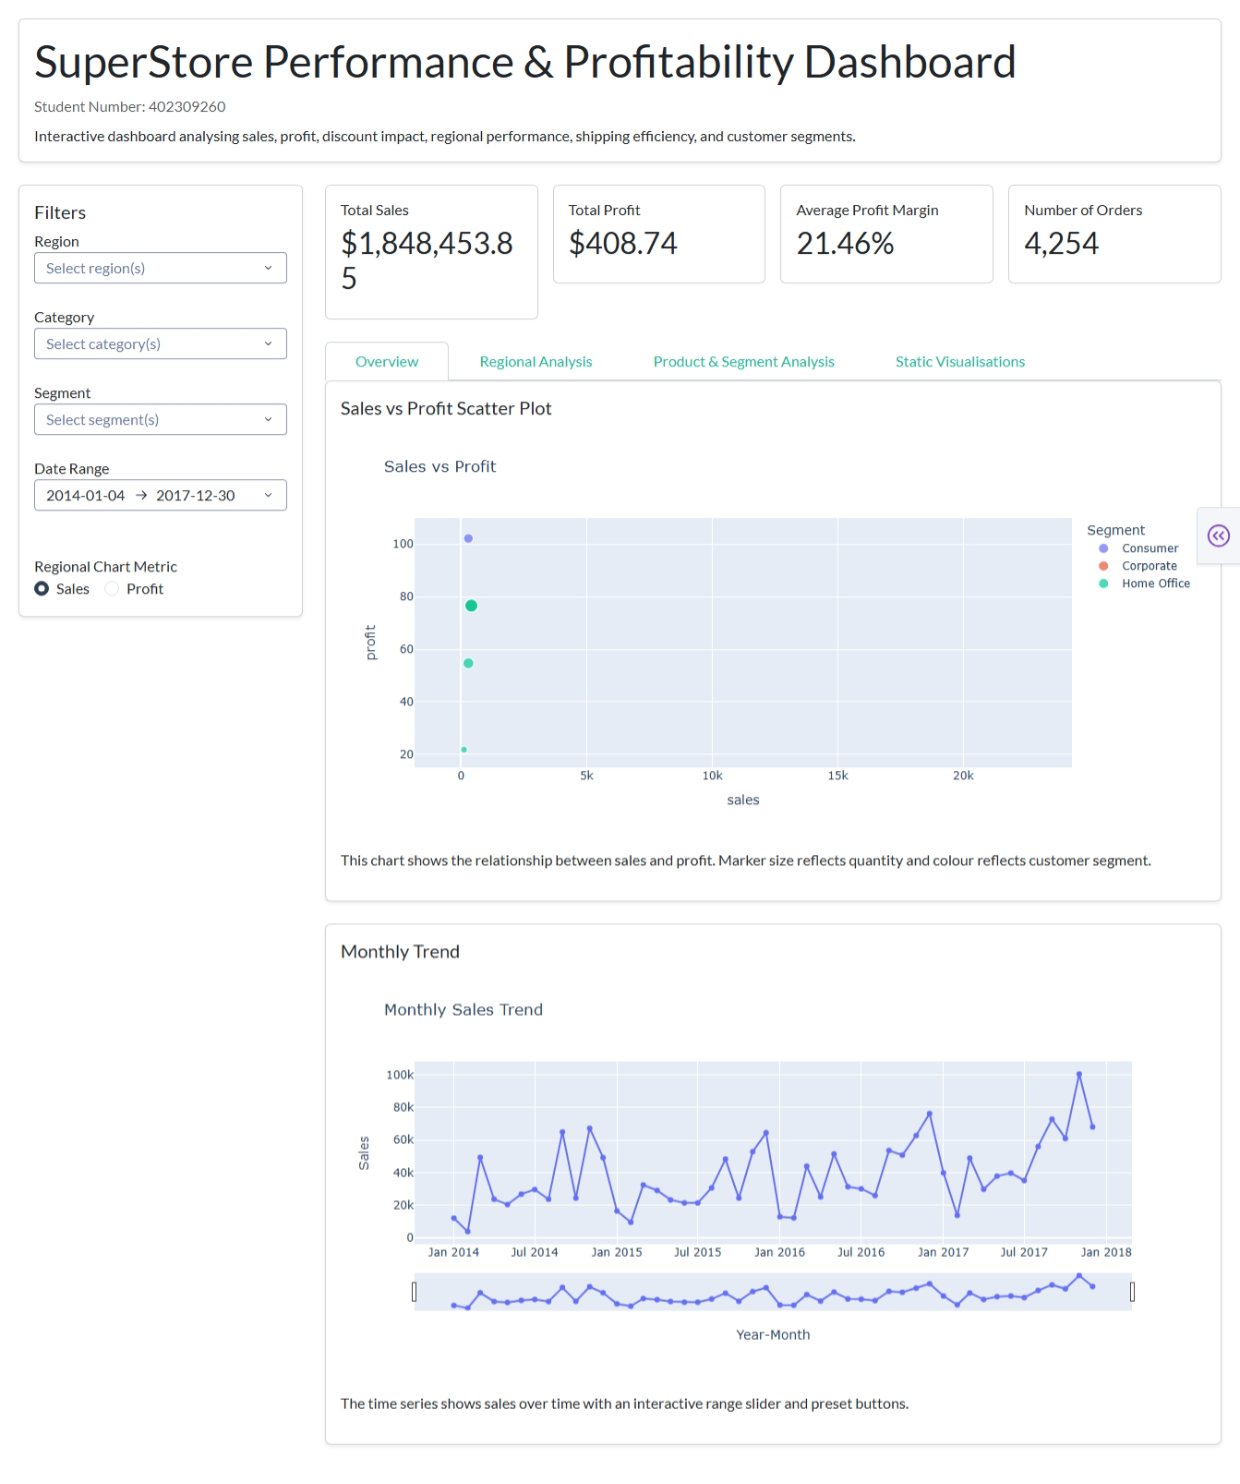

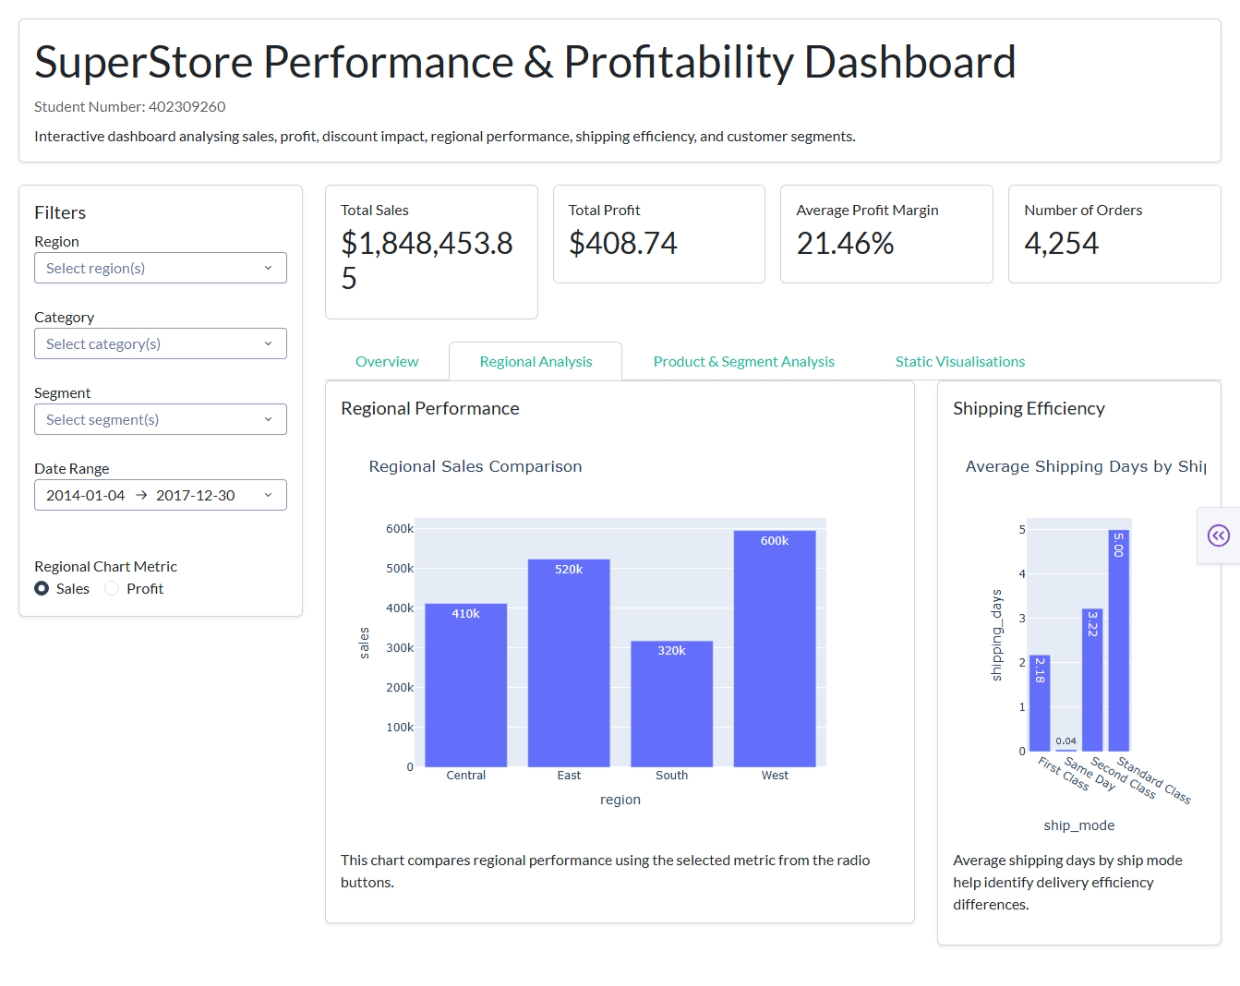

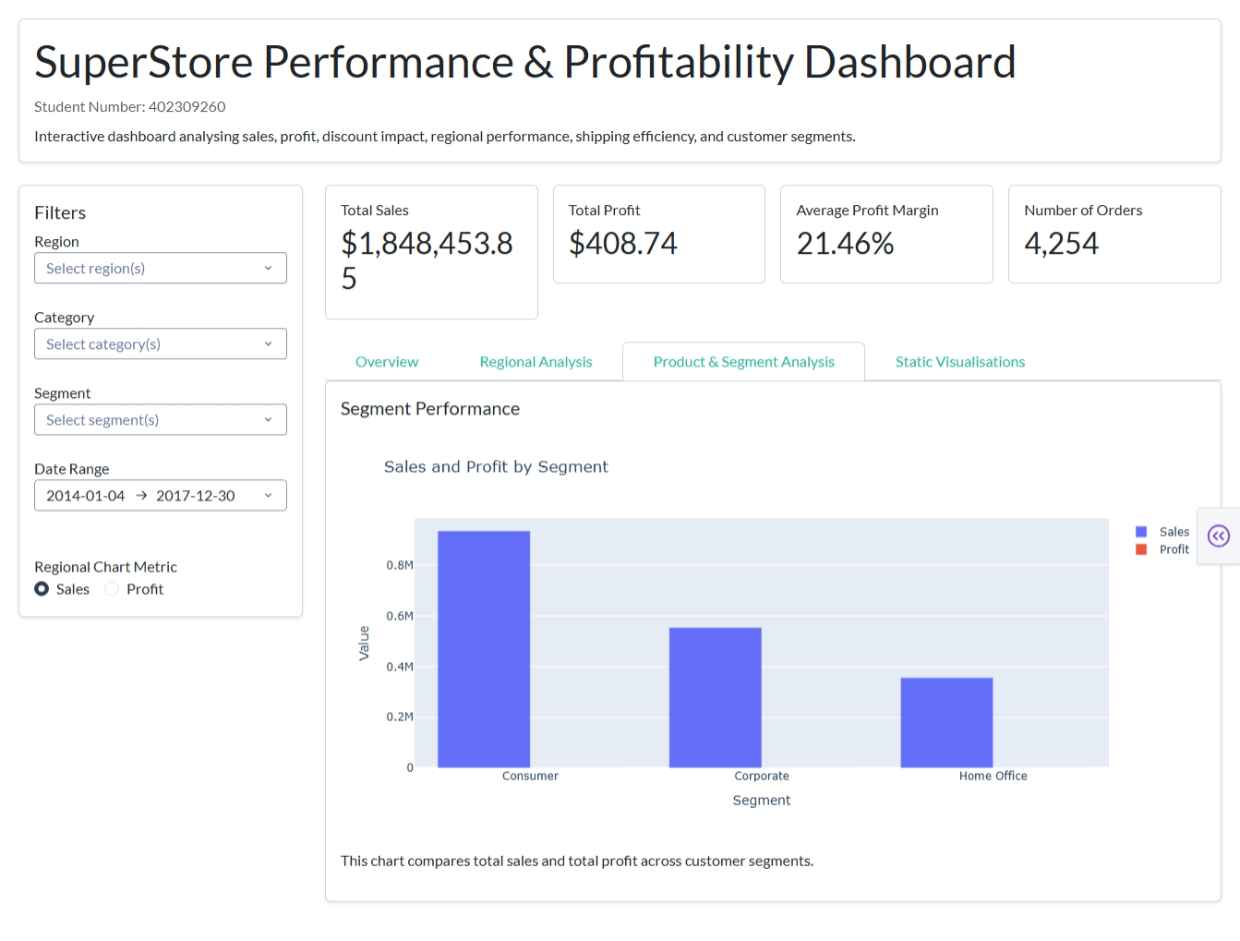

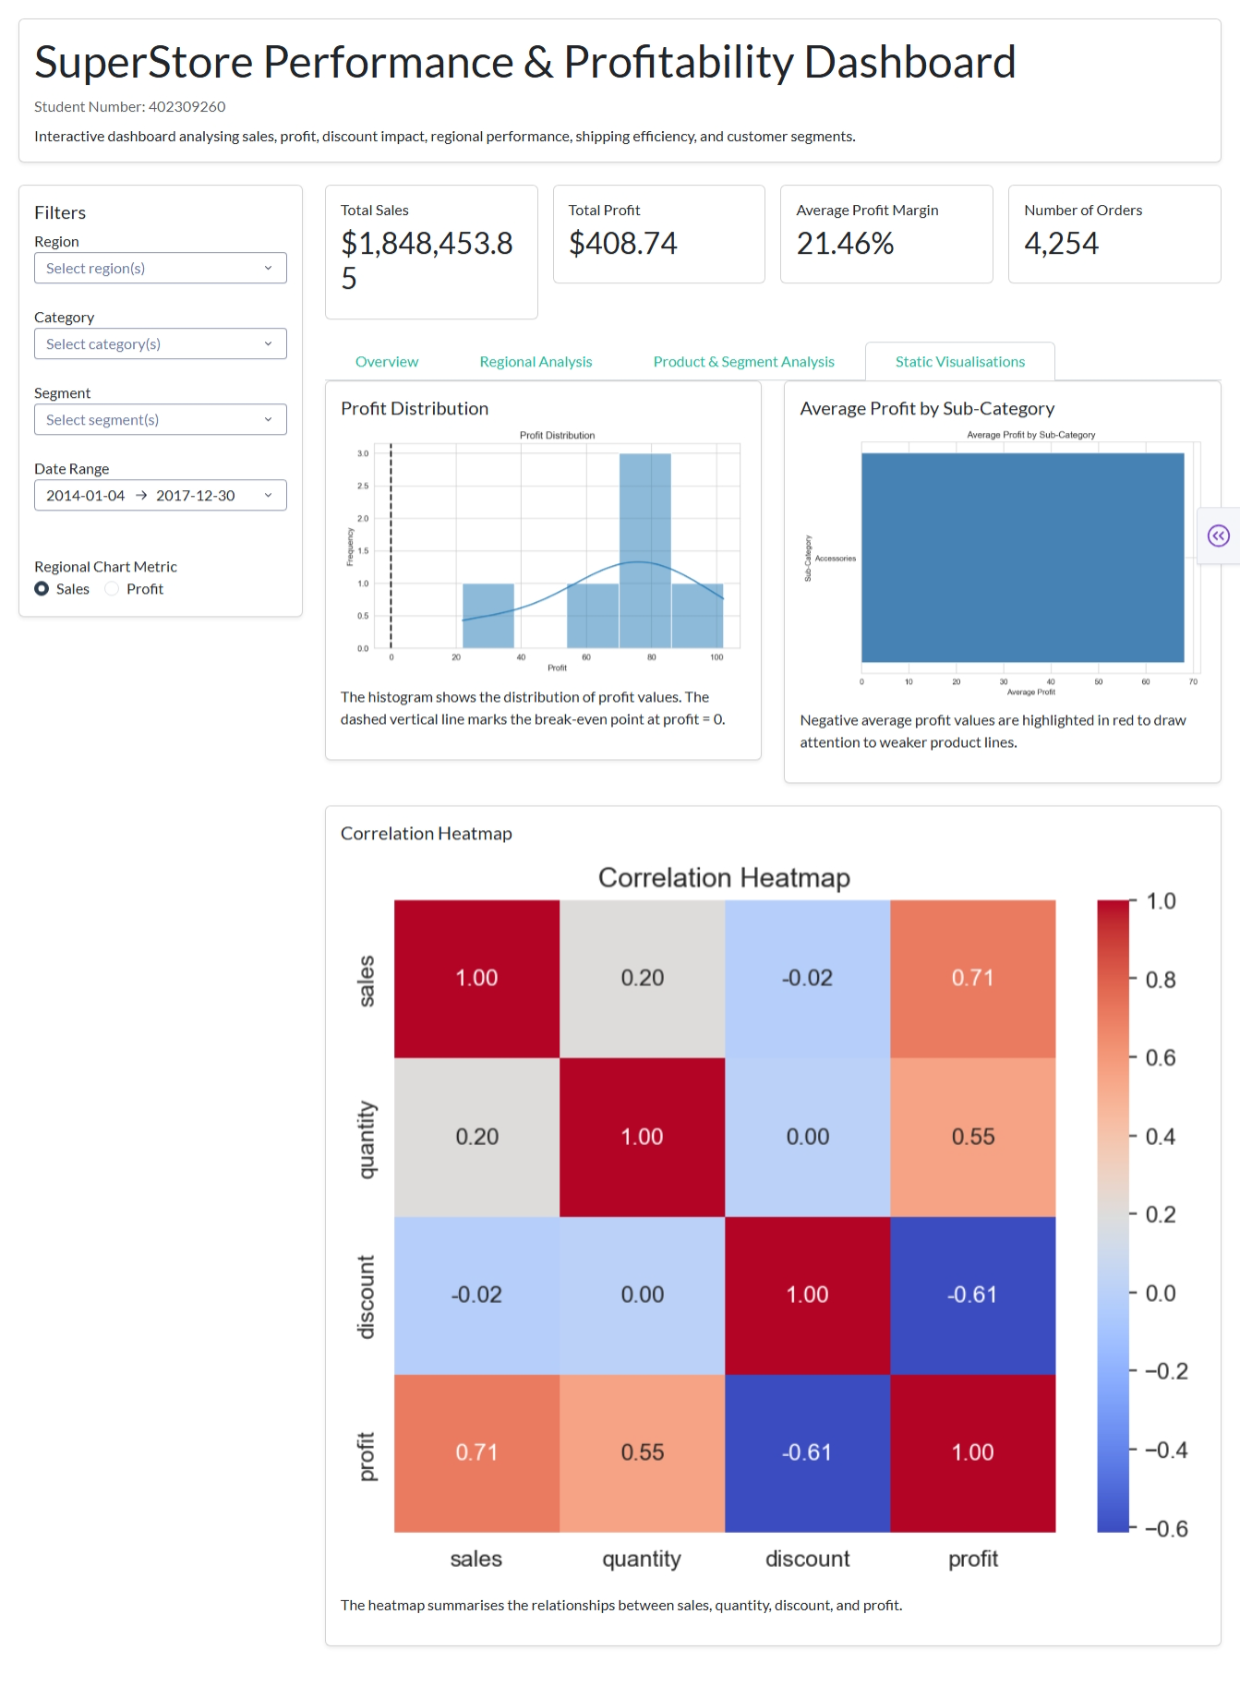


I declare that this assignment is my own work. I did not use AI tools . I understand
that I am responsible for understanding all code submitted and can explain any part of my analysis upon request.